In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

# 1. Simulação (Papel e Celulose)
np.random.seed(42)
n_amostras = 1000

data = {
    'vazao_amido_l_min': np.random.normal(150, 15, n_amostras),  # Amido na Prensa de Colagem
    'vazao_cola_l_min': np.random.normal(45, 8, n_amostras),    # Cola Superficial
    'vel_maquina_m_min': np.random.normal(850, 30, n_amostras), # Velocidade de produção
    'pressao_vapo_bar': np.random.normal(3.5, 0.4, n_amostras)   # Secagem
}

df = pd.DataFrame(data)

# 2. Criando o Alvo (Cobb 60) com lógica física industrial
# Se a velocidade sobe, o Cobb tende a subir (menos tempo de secagem/absorção)
# Se o amido sobe, o Cobb tende a cair (melhor selagem)
df['cobb_60_resultado'] = (
    (df['vel_maquina_m_min'] * 0.04) - 
    (df['vazao_amido_l_min'] * 0.15) + 
    30 + np.random.normal(0, 1.5, n_amostras)
)

# 3. Visualização Profissional para o Cliente
fig = px.scatter(df, x='vazao_amido_l_min', y='cobb_60_resultado', 
                 color='vel_maquina_m_min',
                 title="Correlação Industrial: Vazão de Amido vs Cobb (Colorido por Velocidade)",
                 labels={'vazao_amido_l_min': 'Vazão de Amido (L/min)', 'cobb_60_resultado': 'Teste de Cobb'},
                 template="plotly_dark")
fig.show()

✅ Modelo Treinado! Erro Médio: 1.22 g/m²

📊 Gráfico de Importância das Variáveis (SHAP):


/tmp/ipykernel_670868/850630540.py:26: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


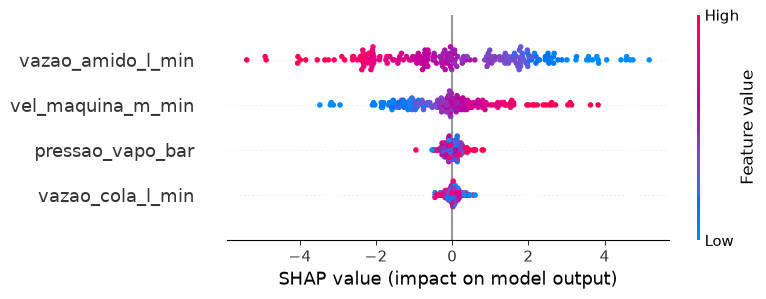

['../models/modelo_cobb_v1.pkl']

In [4]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import shap

# 1. Preparando os dados para a IA
X = df[['vazao_amido_l_min', 'vazao_cola_l_min', 'vel_maquina_m_min', 'pressao_vapo_bar']]
y = df['cobb_60_resultado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Treinando o Modelo (XGBoost - O estado da arte industrial)
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)

# 3. Avaliando (Média de erro em g/m²)
preds = model.predict(X_test)
erro = mean_absolute_error(y_test, preds)
print(f"✅ Modelo Treinado! Erro Médio: {erro:.2f} g/m²")

# 4. EXPLICABILIDADE (O segredo da consultoria sênior)
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

print("\n📊 Gráfico de Importância das Variáveis (SHAP):")
shap.summary_plot(shap_values, X_test)


import joblib
joblib.dump(model, '../models/modelo_cobb_v1.pkl')